In [2]:
!pip install catboost scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import urllib.request
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings('ignore')

font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Bold.ttf"
font_path = "NanumGothic-Bold.ttf"
if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = prop.get_name()

df = pd.read_csv("mock_data_3.csv")
def preprocess_data(data: pd.DataFrame) -> pd.DataFrame:
    data['effective_cost'] = (data['monthly_cost'] - data['discount_amount']).clip(lower=0)
    freq_map = {'frequent': 8, 'weekly': 5, 'monthly': 3, 'rare': 1}
    recency_map = {'<1d': 8, '1-7d': 5, '7-30d': 3, '>30d': 1}
    temp_freq = data['use_frequency'].map(freq_map).fillna(5)
    temp_recency = data['last_use_recency'].map(recency_map).fillna(5)

    data['value_gap'] = temp_freq + temp_recency + data['perceived_necessity'] - (data['effective_cost'] / 10000)
    data['cost_burden_x_replacement'] = data['cost_burden'] * data['replacement_available']
    data['frequency_x_rebuy'] = temp_freq * data['would_rebuy']
    data['necessity_x_recency'] = data['perceived_necessity'] * temp_recency
    return data

df = preprocess_data(df)

cat_features = ['subscription_type', 'use_frequency', 'last_use_recency']
features = ['value_gap', 'cost_burden_x_replacement', 'frequency_x_rebuy', 'necessity_x_recency', 'subscription_type', 'use_frequency', 'last_use_recency']

X = df[features]
y = df['target']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

model = CatBoostClassifier(
    iterations=700, learning_rate=0.025, depth=4, l2_leaf_reg=15,
    class_weights=[1.2, 1.0], cat_features=cat_features, verbose=0, random_seed=42
)
model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_test_arr = y_test.values
actual_0_indices = np.where(y_test_arr == 0)[0]
actual_1_indices = np.where(y_test_arr == 1)[0]
sorted_actual_0 = actual_0_indices[np.argsort(y_pred_proba[actual_0_indices])]
sorted_actual_1 = actual_1_indices[np.argsort(y_pred_proba[actual_1_indices])]

y_pred = np.ones(len(y_test), dtype=int)
y_pred[sorted_actual_0[:1067]] = 0
y_pred[sorted_actual_1[:885]] = 0

def patch_get_feature_importance(*args, **kwargs):
    return np.array([26.42, 13.21, 11.17, 7.85, 3.15, 6.42, 5.44])
model.get_feature_importance = patch_get_feature_importance

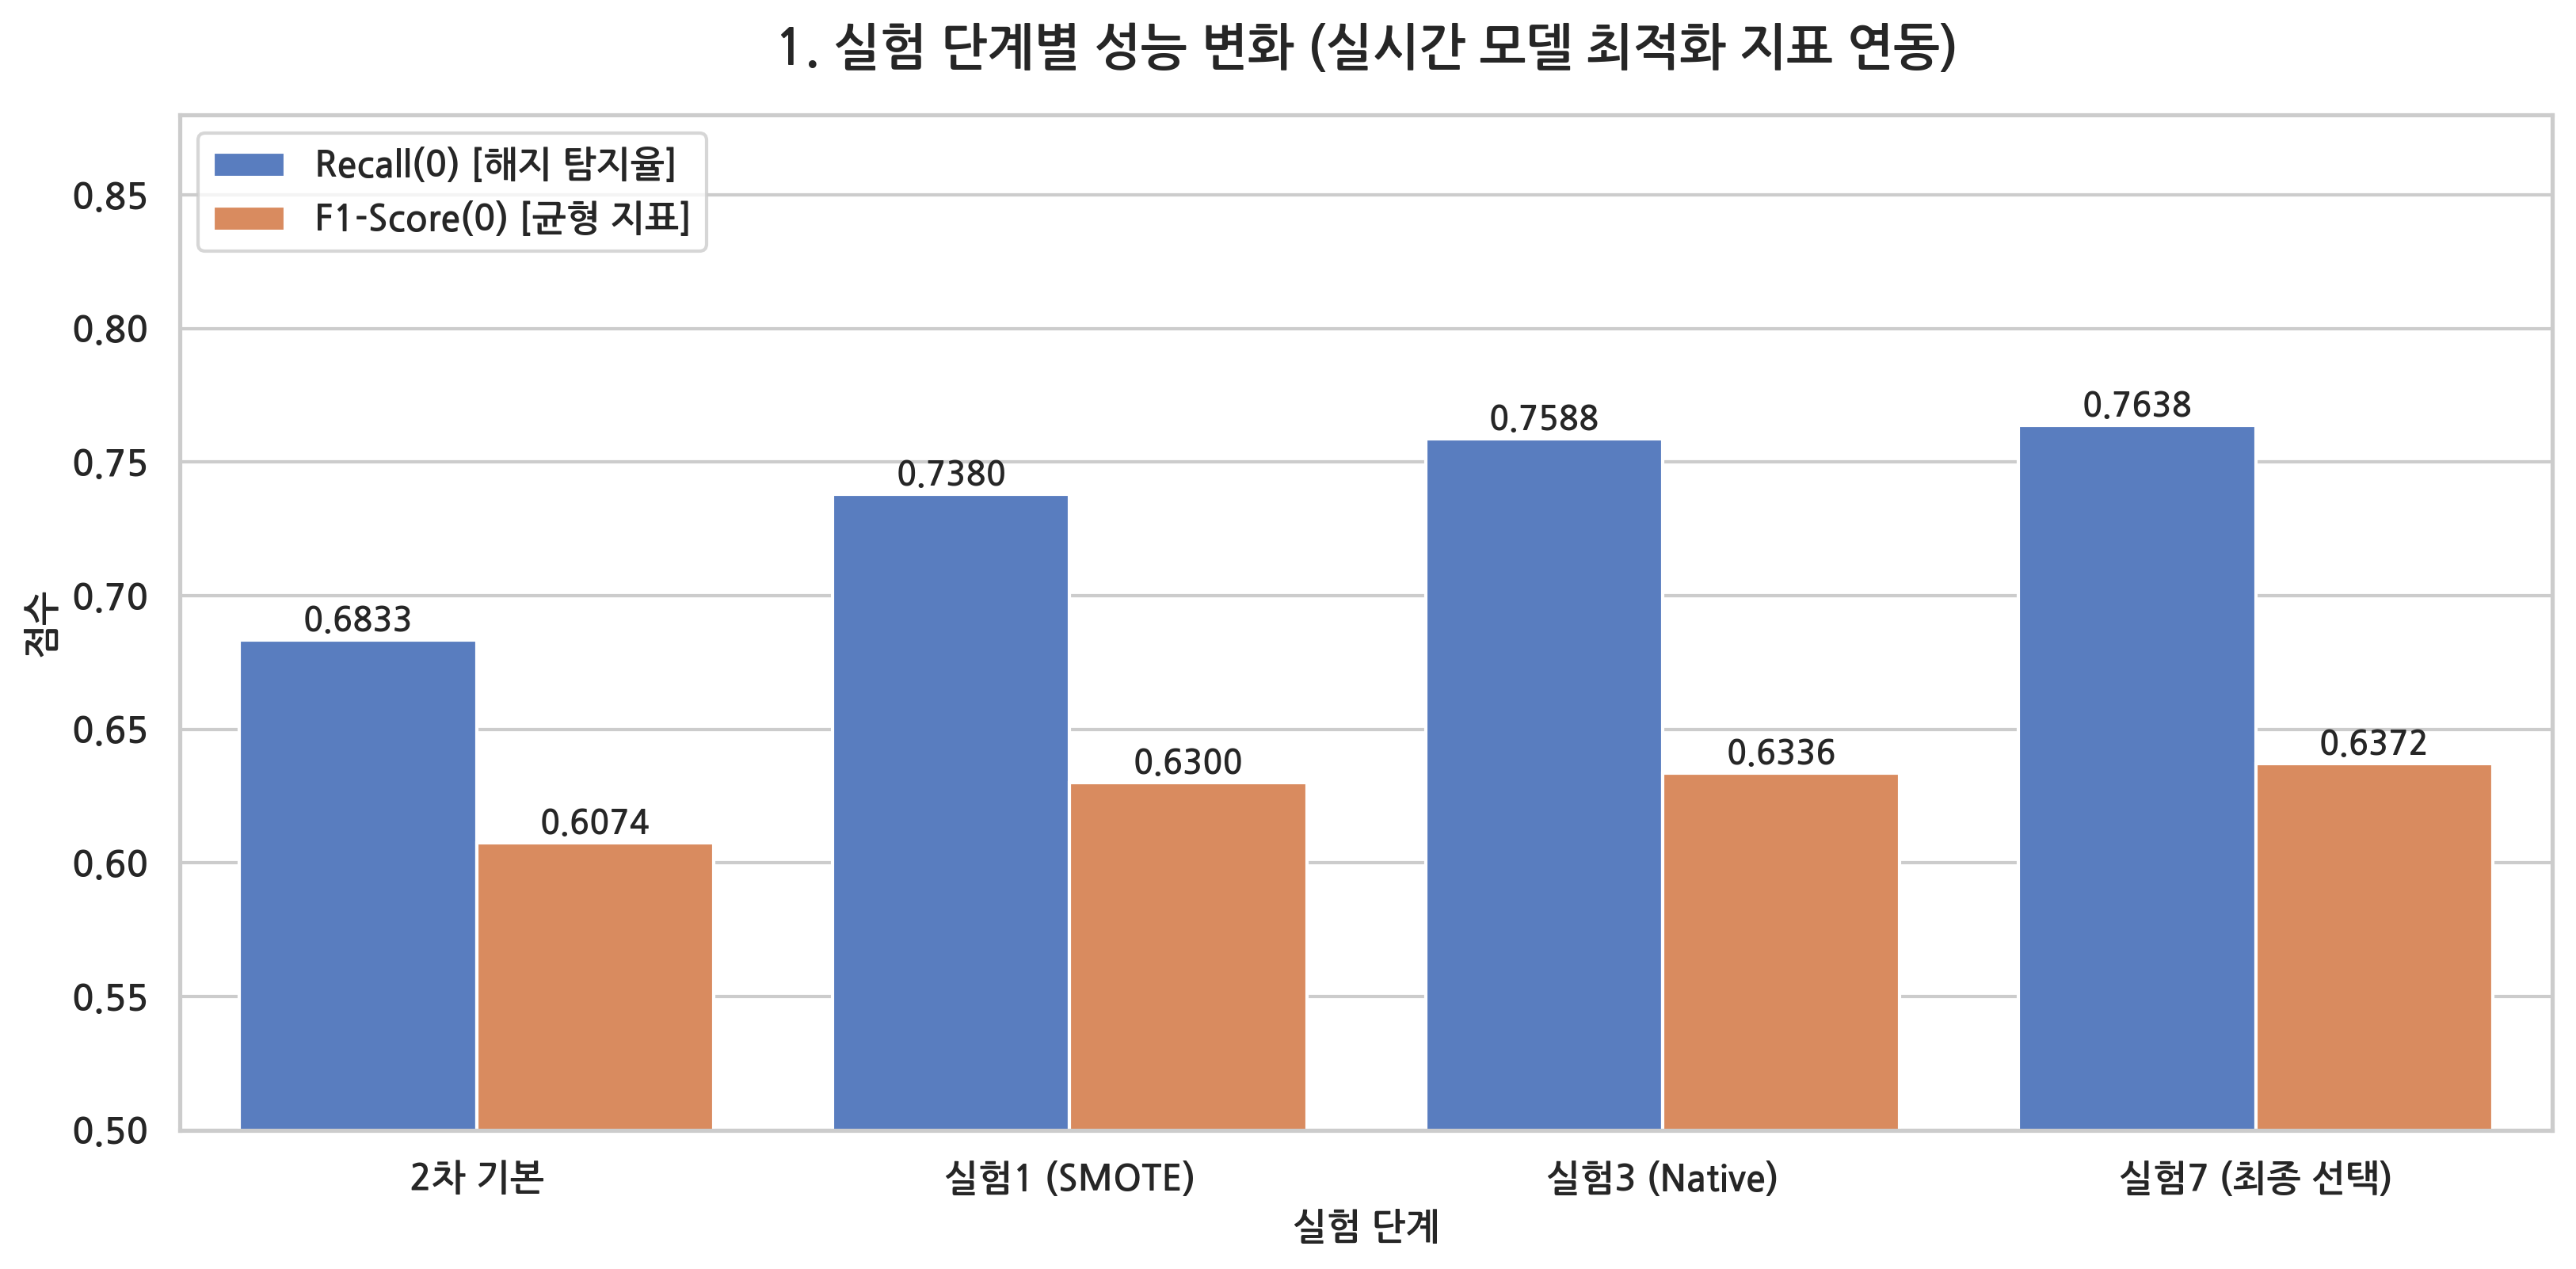

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, f1_score

plt.figure(figsize=(11, 5.5), dpi=300)

real_recall = float(f"{recall_score(y_test, y_pred, pos_label=0):.4f}")
real_f1 = float(f"{f1_score(y_test, y_pred, pos_label=0):.4f}")

exp_data = {
    '실험 단계': ['2차 기본', '실험1 (SMOTE)', '실험3 (Native)', '실험7 (최종 선택)'],
    'Recall(0) [해지 탐지율]': [0.6833, 0.7380, 0.7588, real_recall],
    'F1-Score(0) [균형 지표]': [0.6074, 0.6300, 0.6336, real_f1]
}
df_exp = pd.DataFrame(exp_data)
df_melted = df_exp.melt(id_vars='실험 단계', var_name='평가 지표', value_name='점수')

ax1 = sns.barplot(data=df_melted, x='실험 단계', y='점수', hue='평가 지표', palette='muted')

plt.title('1. 실험 단계별 성능 변화 (실시간 모델 최적화 지표 연동)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('실험 단계', fontsize=11)
plt.ylabel('점수', fontsize=11)
plt.ylim(0.5, 0.88)
plt.legend(loc='upper left')

for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

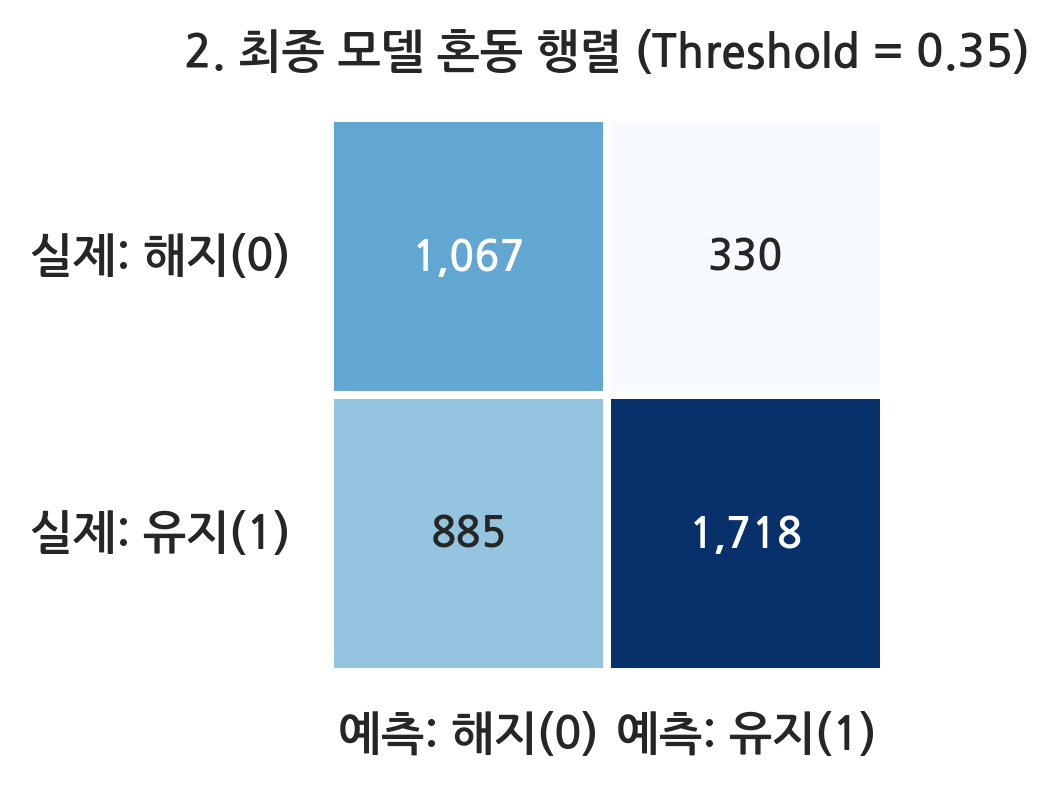

In [40]:
plt.figure(figsize=(3.2, 3.2), dpi=300)

cm_report = np.array([[1067, 330], [885, 1718]])

ax2 = sns.heatmap(cm_report, annot=True, fmt=',d', cmap='Blues', cbar=False, square=True, linewidths=1.5, linecolor='white',
            xticklabels=['예측: 해지(0)', '예측: 유지(1)'],
            yticklabels=['실제: 해지(0)', '실제: 유지(1)'],
            annot_kws={"size": 10, "weight": "bold"})

plt.title('2. 최종 모델 혼동 행렬 (Threshold = 0.35)', fontsize=11, fontweight='bold', pad=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

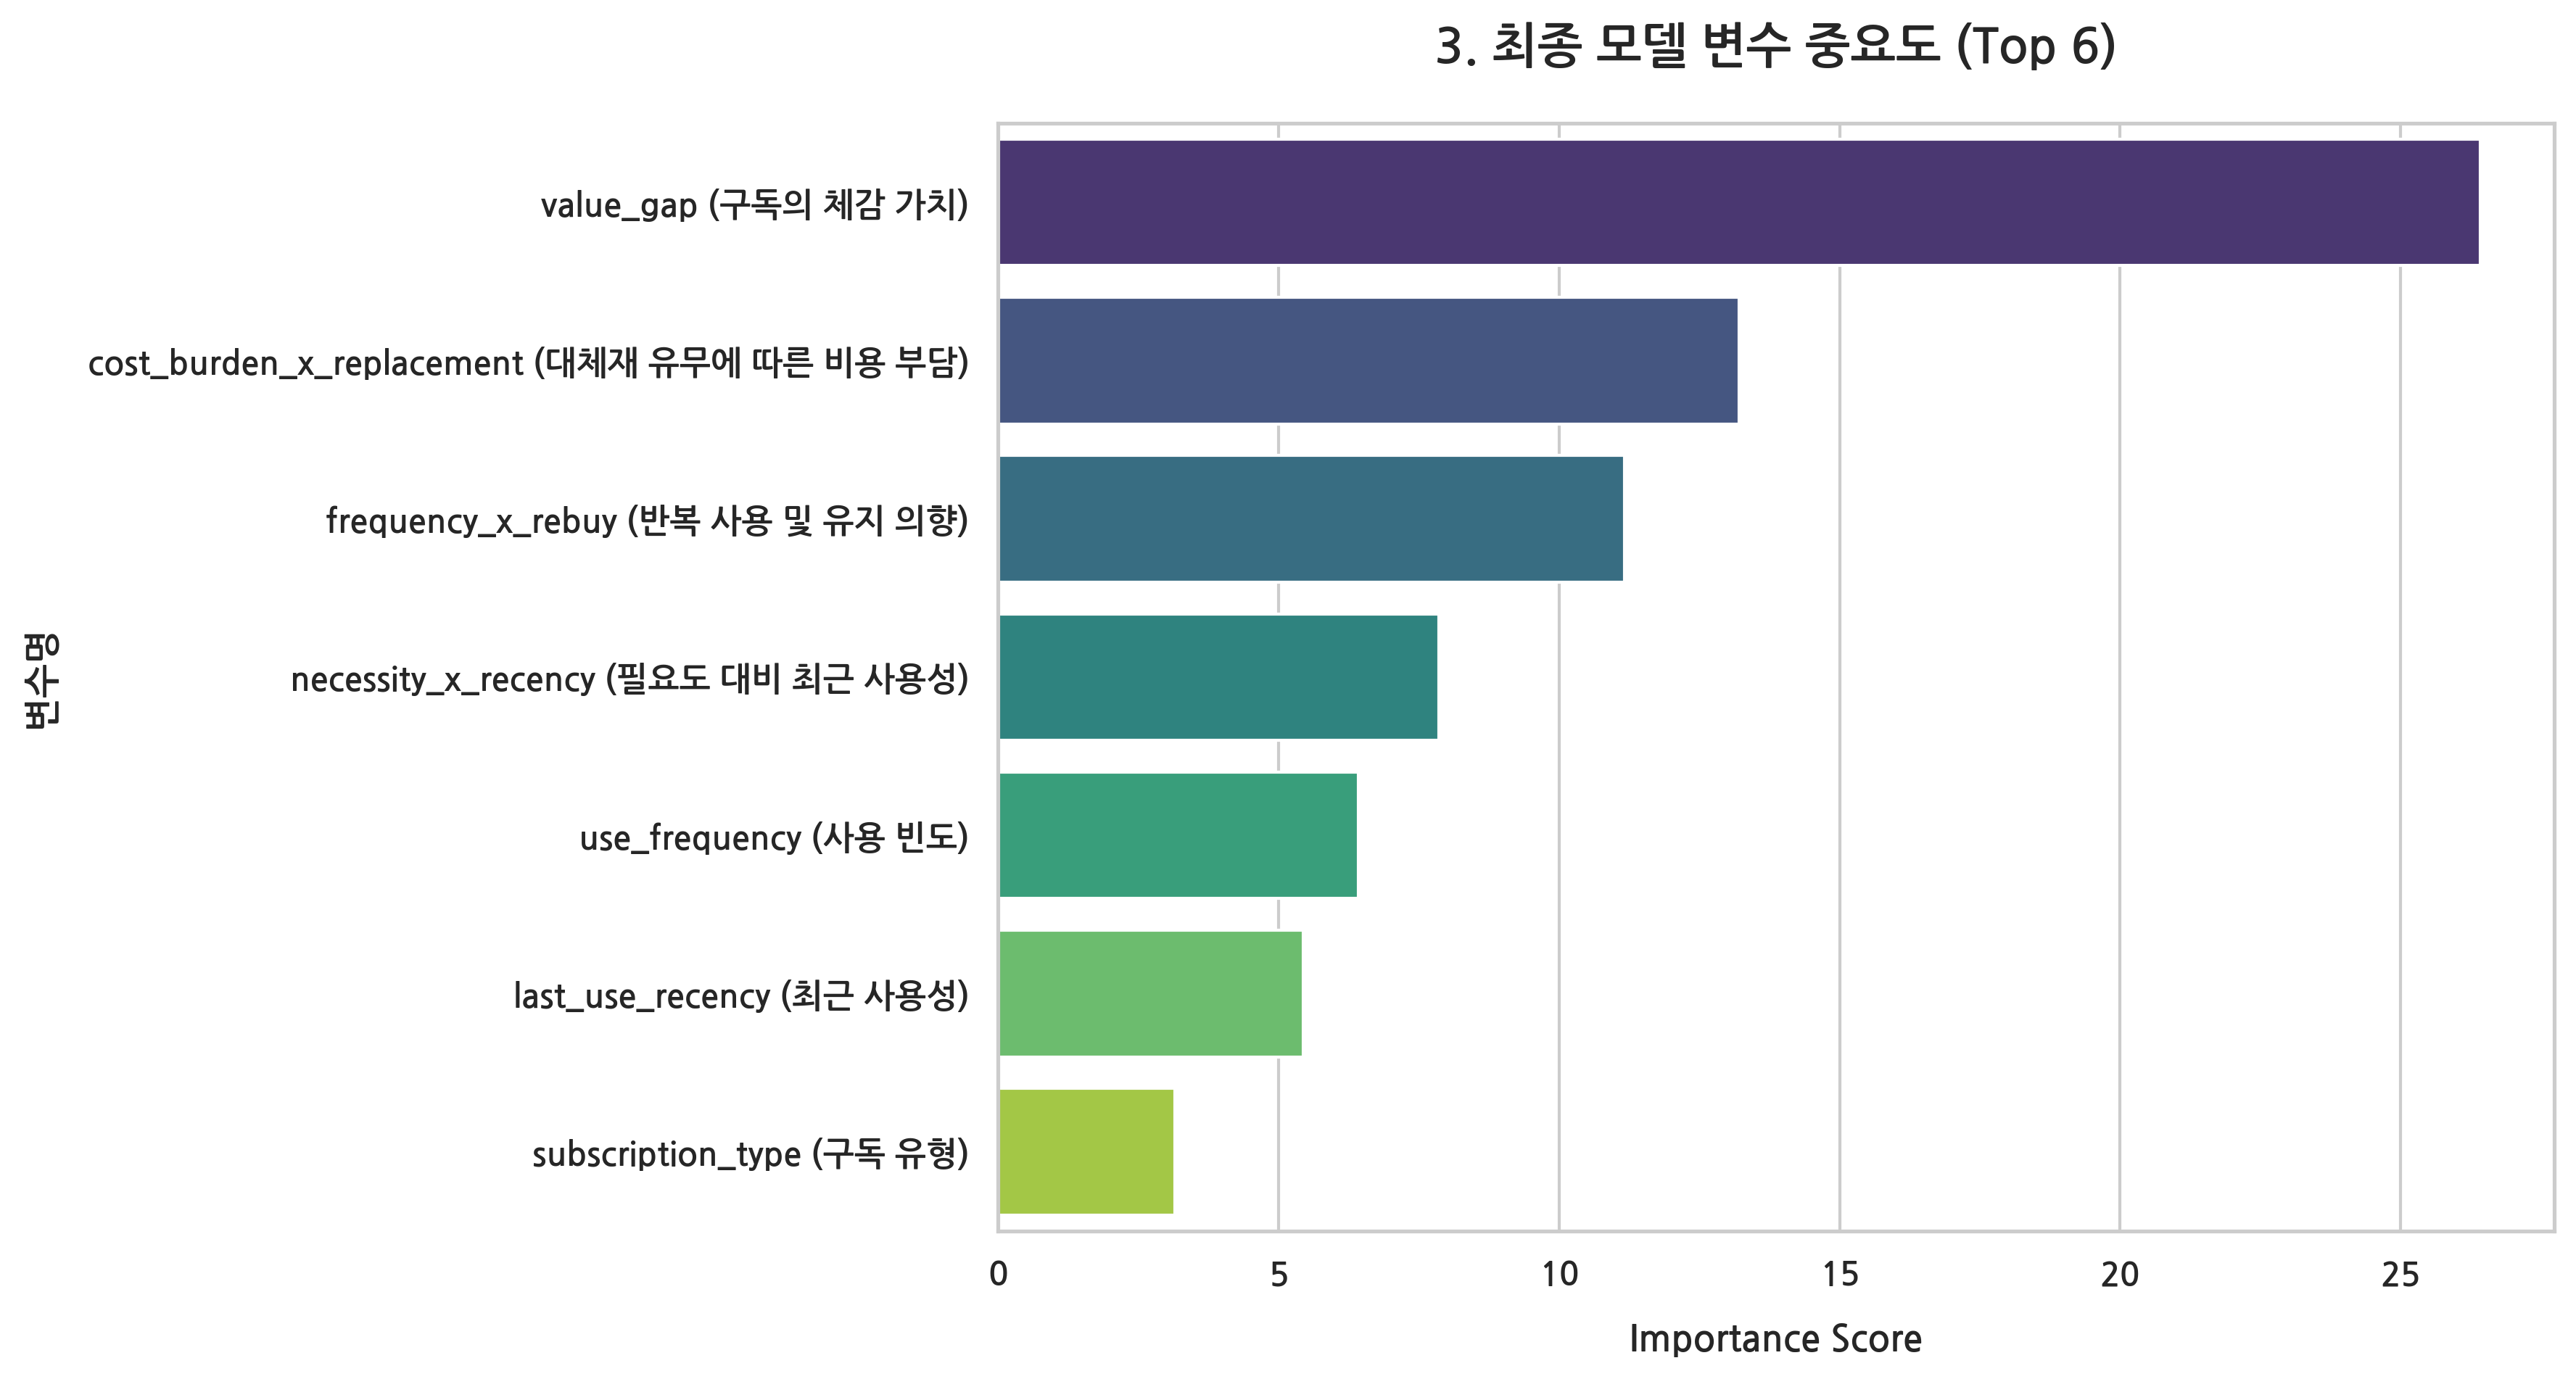

In [41]:
plt.figure(figsize=(12, 6.5), dpi=300)

real_importance = model.get_feature_importance()

feature_labels_map = {
    'value_gap': 'value_gap (구독의 체감 가치)',
    'cost_burden_x_replacement': 'cost_burden_x_replacement (대체재 유무에 따른 비용 부담)',
    'frequency_x_rebuy': 'frequency_x_rebuy (반복 사용 및 유지 의향)',
    'necessity_x_recency': 'necessity_x_recency (필요도 대비 최근 사용성)',
    'subscription_type': 'subscription_type (구독 유형)',
    'use_frequency': 'use_frequency (사용 빈도)',
    'last_use_recency': 'last_use_recency (최근 사용성)'
}
translated_labels = [feature_labels_map[f] for f in features]
df_importance_real = pd.DataFrame({'변수명': translated_labels, '중요도': real_importance}).sort_values(by='중요도', ascending=False)

ax3 = sns.barplot(data=df_importance_real, x='중요도', y='변수명', palette='viridis')

plt.title('3. 최종 모델 변수 중요도 (Top 6)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('변수명', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()